<a href="https://colab.research.google.com/github/Sejalm18/MBA-Projects/blob/main/HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error

df = pd.read_csv('elantra.csv')
print(df.head())
print(df.shape)
print(df.dtypes)

   time  Month  Year  ElantraSales  Unemployment  Queries  CPI_energy  CPI_all
0     1      1  2010          7690           9.7      153     213.377  217.466
1     2      2  2010          7966           9.8      130     209.924  217.251
2     3      3  2010          8225           9.9      138     209.163  217.305
3     4      4  2010          9657           9.9      132     209.024  217.376
4     5      5  2010          9781           9.6      177     206.172  217.299
(50, 8)
time              int64
Month             int64
Year              int64
ElantraSales      int64
Unemployment    float64
Queries           int64
CPI_energy      float64
CPI_all         float64
dtype: object


In [ ]:
train = df[df['Year'].isin([2010, 2011, 2012])].copy()
test  = df[df['Year'].isin([2013, 2014])].copy()

print("Training obs:", len(train))
print("Avg ElantraSales:", train['ElantraSales'].mean().round(2))

features_a = ['Unemployment', 'Queries', 'CPI_all', 'CPI_energy']
X_train_a = sm.add_constant(train[features_a])
y_train   = train['ElantraSales']
y_test    = test['ElantraSales']

model_a = sm.OLS(y_train, X_train_a).fit()
print(model_a.summary())

Training obs: 36
Avg ElantraSales: 14462.25
                            OLS Regression Results                            
Dep. Variable:           ElantraSales   R-squared:                       0.428
Model:                            OLS   Adj. R-squared:                  0.354
Method:                 Least Squares   F-statistic:                     5.803
Date:                Sat, 04 Apr 2026   Prob (F-statistic):            0.00132
Time:                        21:38:24   Log-Likelihood:                -339.99
No. Observations:                  36   AIC:                             690.0
Df Residuals:                      31   BIC:                             697.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
cons

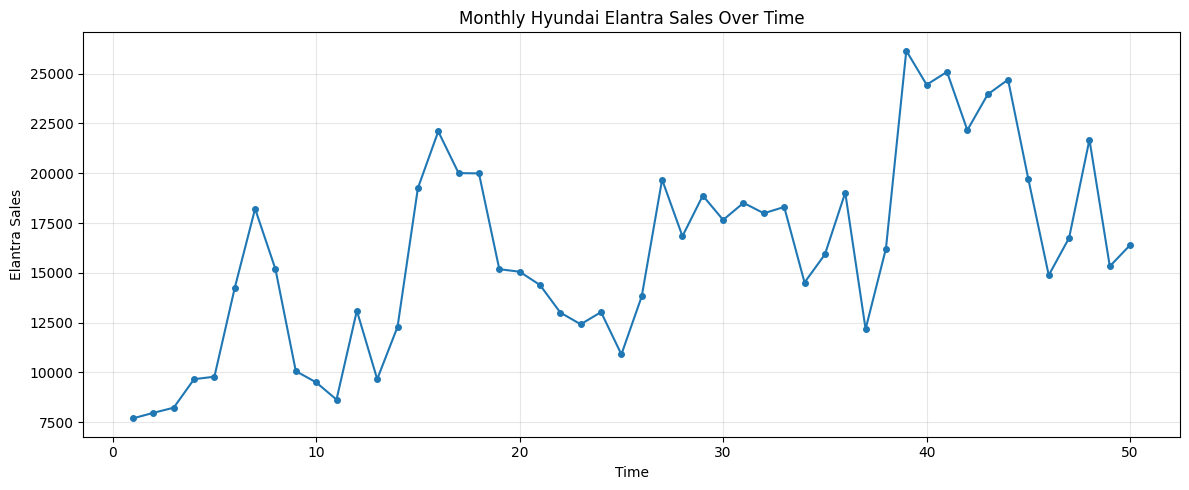

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(df['time'], df['ElantraSales'],
         marker='o', linewidth=1.5, markersize=4)
plt.xlabel('Time')
plt.ylabel('Elantra Sales')
plt.title('Monthly Hyundai Elantra Sales Over Time')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sales_over_time.png', dpi=150)
plt.show()

In [ ]:
features_c = ['Unemployment', 'Queries', 'CPI_all', 'CPI_energy', 'Month']
X_train_c  = sm.add_constant(train[features_c])

model_c = sm.OLS(y_train, X_train_c).fit()
print(model_c.summary())

                            OLS Regression Results                            
Dep. Variable:           ElantraSales   R-squared:                       0.434
Model:                            OLS   Adj. R-squared:                  0.340
Method:                 Least Squares   F-statistic:                     4.609
Date:                Sat, 04 Apr 2026   Prob (F-statistic):            0.00308
Time:                        21:39:42   Log-Likelihood:                -339.79
No. Observations:                  36   AIC:                             691.6
Df Residuals:                      30   BIC:                             701.1
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         1.483e+05   1.95e+05      0.759   

In [ ]:
train_d = train.copy()
test_d  = test.copy()
train_d['Month'] = train_d['Month'].astype('category')
test_d['Month']  = test_d['Month'].astype('category')

train_dummies = pd.get_dummies(train_d['Month'],
                               prefix='Month', drop_first=True).astype(int)
test_dummies  = pd.get_dummies(test_d['Month'],
                               prefix='Month', drop_first=True).astype(int)
test_dummies  = test_dummies.reindex(
    columns=train_dummies.columns, fill_value=0)

base_feats = ['Unemployment', 'Queries', 'CPI_all', 'CPI_energy']

X_train_d = sm.add_constant(
    pd.concat([train_d[base_feats], train_dummies], axis=1))
X_test_d  = sm.add_constant(
    pd.concat([test_d[base_feats], test_dummies], axis=1))

model_d = sm.OLS(y_train, X_train_d).fit()
print(model_d.summary())

                            OLS Regression Results                            
Dep. Variable:           ElantraSales   R-squared:                       0.819
Model:                            OLS   Adj. R-squared:                  0.684
Method:                 Least Squares   F-statistic:                     6.044
Date:                Sat, 04 Apr 2026   Prob (F-statistic):           0.000147
Time:                        21:40:45   Log-Likelihood:                -319.26
No. Observations:                  36   AIC:                             670.5
Df Residuals:                      20   BIC:                             695.9
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         3.125e+05   1.44e+05      2.169   

In [ ]:
imp_feats = ['Unemployment', 'Queries', 'CPI_all']

X_train_imp = sm.add_constant(
    pd.concat([train_d[imp_feats], train_dummies], axis=1))
X_test_imp  = sm.add_constant(
    pd.concat([test_d[imp_feats], test_dummies], axis=1))

model_imp = sm.OLS(y_train, X_train_imp).fit()
print(model_imp.summary())

print("Model (d)(i) AIC:", round(model_d.aic, 2))
print("Model (d)(ii) AIC:", round(model_imp.aic, 2))

                            OLS Regression Results                            
Dep. Variable:           ElantraSales   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.568
Method:                 Least Squares   F-statistic:                     4.288
Date:                Sat, 04 Apr 2026   Prob (F-statistic):            0.00139
Time:                        21:41:01   Log-Likelihood:                -325.75
No. Observations:                  36   AIC:                             681.5
Df Residuals:                      21   BIC:                             705.2
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         9.985e+04   1.46e+05      0.685   

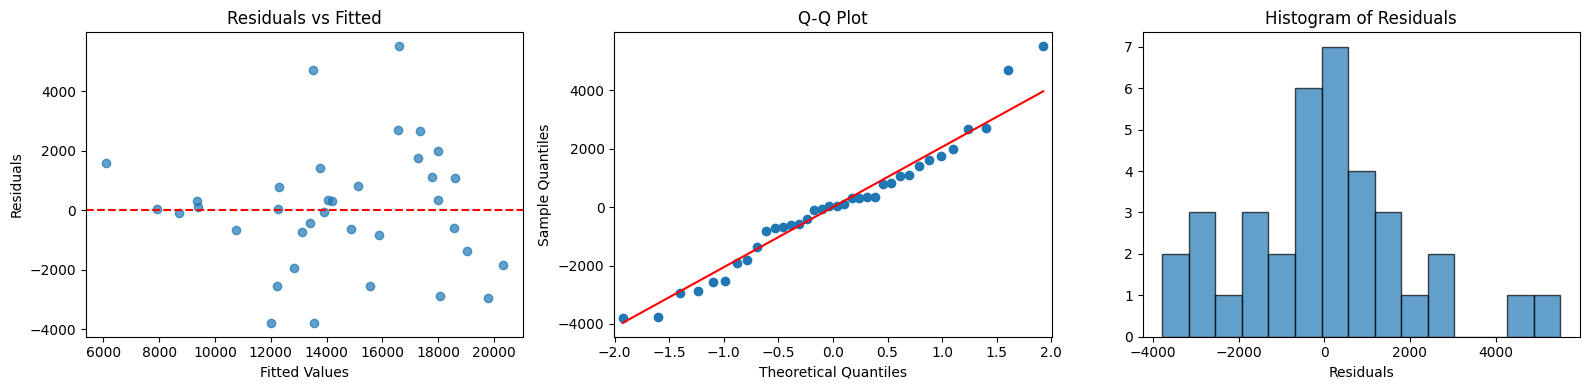

In [ ]:
residuals = model_imp.resid
fitted    = model_imp.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(fitted, residuals, alpha=0.7)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title('Q-Q Plot')

axes[2].hist(residuals, bins=15, edgecolor='black', alpha=0.7)
axes[2].set_xlabel('Residuals')
axes[2].set_title('Histogram of Residuals')

plt.tight_layout()
plt.savefig('diagnostics.png', dpi=150)
plt.show()

In [ ]:
X_test_a = sm.add_constant(test[['Unemployment', 'Queries', 'CPI_all', 'CPI_energy']])

def evaluate(model, X_test, y_test, label):
    preds  = model.predict(X_test)
    ss_res = np.sum((y_test - preds) ** 2)
    ss_tot = np.sum((y_test - y_test.mean()) ** 2)
    r2   = 1 - ss_res / ss_tot
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae  = mean_absolute_error(y_test, preds)
    print(f"\n{label}")
    print(f"  R²   : {round(r2, 4)}")
    print(f"  RMSE : {round(rmse, 2)}")
    print(f"  MAE  : {round(mae, 2)}")
    return preds

evaluate(model_a,   X_test_a,   y_test, "Model (a)")
evaluate(model_imp, X_test_imp, y_test, "Model (d)(ii) improved")


Model (a)
  R²   : -0.2764
  RMSE : 5017.35
  MAE  : 4094.7

Model (d)(ii) improved
  R²   : 0.5366
  RMSE : 3023.3
  MAE  : 2292.78


,0
36,10949.641524
37,14148.873844
38,20696.757314
39,20012.027028
40,19331.740758
41,21468.165054
42,20228.132165
43,20073.721030
44,18384.939288
45,15471.211031


In [ ]:
import statsmodels.api as sm
import pandas as pd # Adding this as well, as it's used in pd.concat

imp_feats = ['Unemployment', 'CPI_all']

X_train_e = sm.add_constant(
    pd.concat([train_d[imp_feats], train_dummies,
               train_d[['time']]], axis=1))
X_test_e  = sm.add_constant(
    pd.concat([test_d[imp_feats], test_dummies,
               test_d[['time']]], axis=1))

model_e = sm.OLS(y_train, X_train_e).fit()
print(model_e.summary())

preds_e = evaluate(model_e, X_test_e, y_test, "Model (e) with time")

plt.figure(figsize=(10, 4))
plt.plot(test['time'].values, y_test.values,
         label='Actual', marker='o')
plt.plot(test['time'].values, preds_e.values,
         label='Predicted', marker='s', linestyle='--')
plt.xlabel('Time')
plt.ylabel('Elantra Sales')
plt.title('Actual vs Predicted — Test Set (Model e)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()

NameError: name 'sm' is not defined